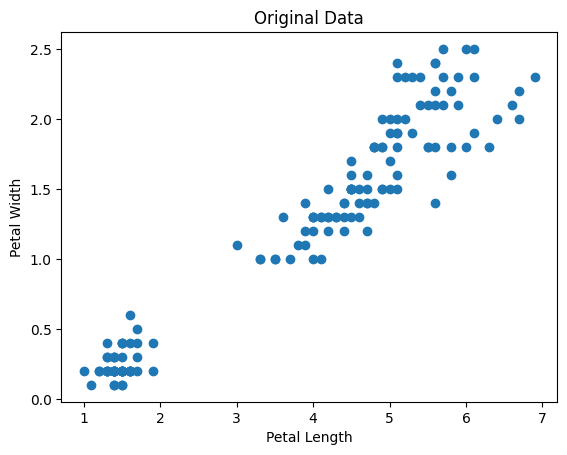

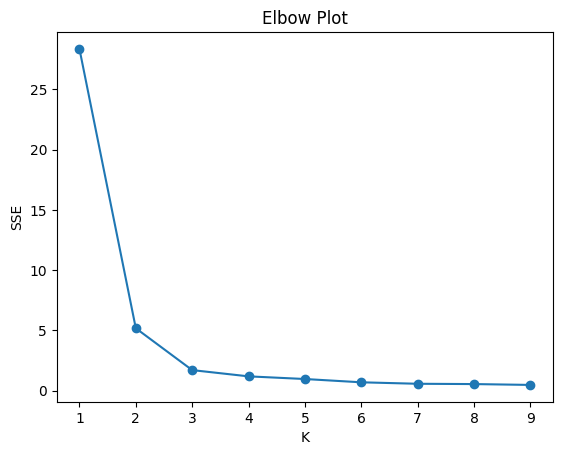

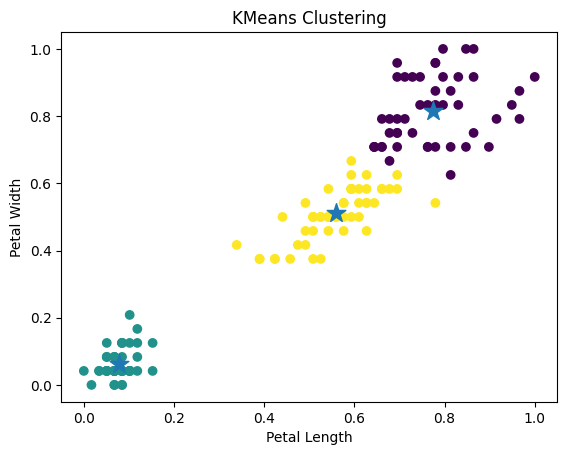

   petal length (cm)  petal width (cm)  cluster
0           0.067797          0.041667        1
1           0.067797          0.041667        1
2           0.050847          0.041667        1
3           0.084746          0.041667        1
4           0.067797          0.041667        1


In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load iris dataset
iris = load_iris()

# Create dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Use only petal length and petal width
df = df[['petal length (cm)', 'petal width (cm)']]

# Scatter plot before clustering
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Original Data")
plt.show()

# Scaling
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(
    df_scaled,
    columns=['petal length (cm)', 'petal width (cm)']
)

# Elbow method
sse = []

k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    sse.append(km.inertia_)

# Elbow plot
plt.plot(k_range, sse, marker='o')
plt.xlabel("K")
plt.ylabel("SSE")
plt.title("Elbow Plot")
plt.show()

# Optimal K = 3
km = KMeans(n_clusters=3, random_state=42)

y_pred = km.fit_predict(df_scaled)

# Add cluster column
df_scaled['cluster'] = y_pred

# Cluster centers
centers = km.cluster_centers_

# Final clustered plot
plt.scatter(
    df_scaled['petal length (cm)'],
    df_scaled['petal width (cm)'],
    c=df_scaled['cluster']
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='*',
    s=200
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KMeans Clustering")
plt.show()

# Print first few rows
print(df_scaled.head())